In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

In [20]:
# Функції оптимізації

def ackley(x, y):
    return -20*np.exp(-0.2*np.sqrt(0.5*(x**2+y**2))) \
           -np.exp(0.5*(np.cos(2*np.pi*x)+np.cos(2*np.pi*y))) \
           +np.e+20


def rosenbrock(x, y):
    return (1-x)**2 + 100*(y-x**2)**2


def cross_in_tray(x, y):
    return -0.0001*(np.abs(
        np.sin(x)*np.sin(y) *
        np.exp(np.abs(100-np.sqrt(x**2+y**2)/np.pi))
    )+1)**0.1


def holder_table(x, y):
    return -np.abs(
        np.sin(x)*np.cos(y) *
        np.exp(np.abs(1-np.sqrt(x**2+y**2)/np.pi))
    )


def mccormick(x, y):
    return np.sin(x+y)+(x-y)**2-1.5*x+2.5*y+1


def styblinski_tang(x, y):
    return 0.5*((x**4-16*x**2+5*x)+(y**4-16*y**2+5*y))

In [21]:
# PSO алгоритм
def pso_2d(func, bounds,
           swarm_size=80,
           iterations=80,
           w=0.7,
           c1=1.5,
           c2=1.5):

    (xmin, xmax), (ymin, ymax) = bounds

    pos = np.column_stack((
        np.random.uniform(xmin, xmax, swarm_size),
        np.random.uniform(ymin, ymax, swarm_size)
    ))

    vel = np.random.uniform(-1, 1, (swarm_size, 2))

    pbest = pos.copy()
    pbest_val = func(pos[:,0], pos[:,1])

    gbest_idx = np.argmin(pbest_val)
    gbest = pbest[gbest_idx]

    history = []
    populations = []

    for _ in range(iterations):

        populations.append(pos.copy())

        r1 = np.random.rand(swarm_size,2)
        r2 = np.random.rand(swarm_size,2)

        vel = (
            w*vel
            + c1*r1*(pbest-pos)
            + c2*r2*(gbest-pos)
        )

        pos = pos + vel

        pos[:,0] = np.clip(pos[:,0], xmin, xmax)
        pos[:,1] = np.clip(pos[:,1], ymin, ymax)

        values = func(pos[:,0], pos[:,1])

        better = values < pbest_val
        pbest[better] = pos[better]
        pbest_val[better] = values[better]

        gbest_idx = np.argmin(pbest_val)
        gbest = pbest[gbest_idx]

        history.append(pbest_val[gbest_idx])

    return gbest, pbest_val[gbest_idx], history, populations



In [22]:
# GIF анімація
def save_gif_3d(func, bounds, populations, history, filename):

    (xmin, xmax), (ymin, ymax) = bounds

    x = np.linspace(xmin, xmax, 200)
    y = np.linspace(ymin, ymax, 200)

    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.6)

    scat = ax.scatter([], [], [], c="red", s=40)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(np.min(Z), np.max(Z))

    def update(frame):

        pop = populations[frame]
        z_vals = func(pop[:,0], pop[:,1])

        scat._offsets3d = (pop[:,0], pop[:,1], z_vals)

        ax.set_title(f"Iteration {frame} | Best = {history[frame]:.5f}")

        return scat,

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(populations),
        interval=200
    )

    ani.save(filename, writer="pillow", fps=5)

    plt.close()


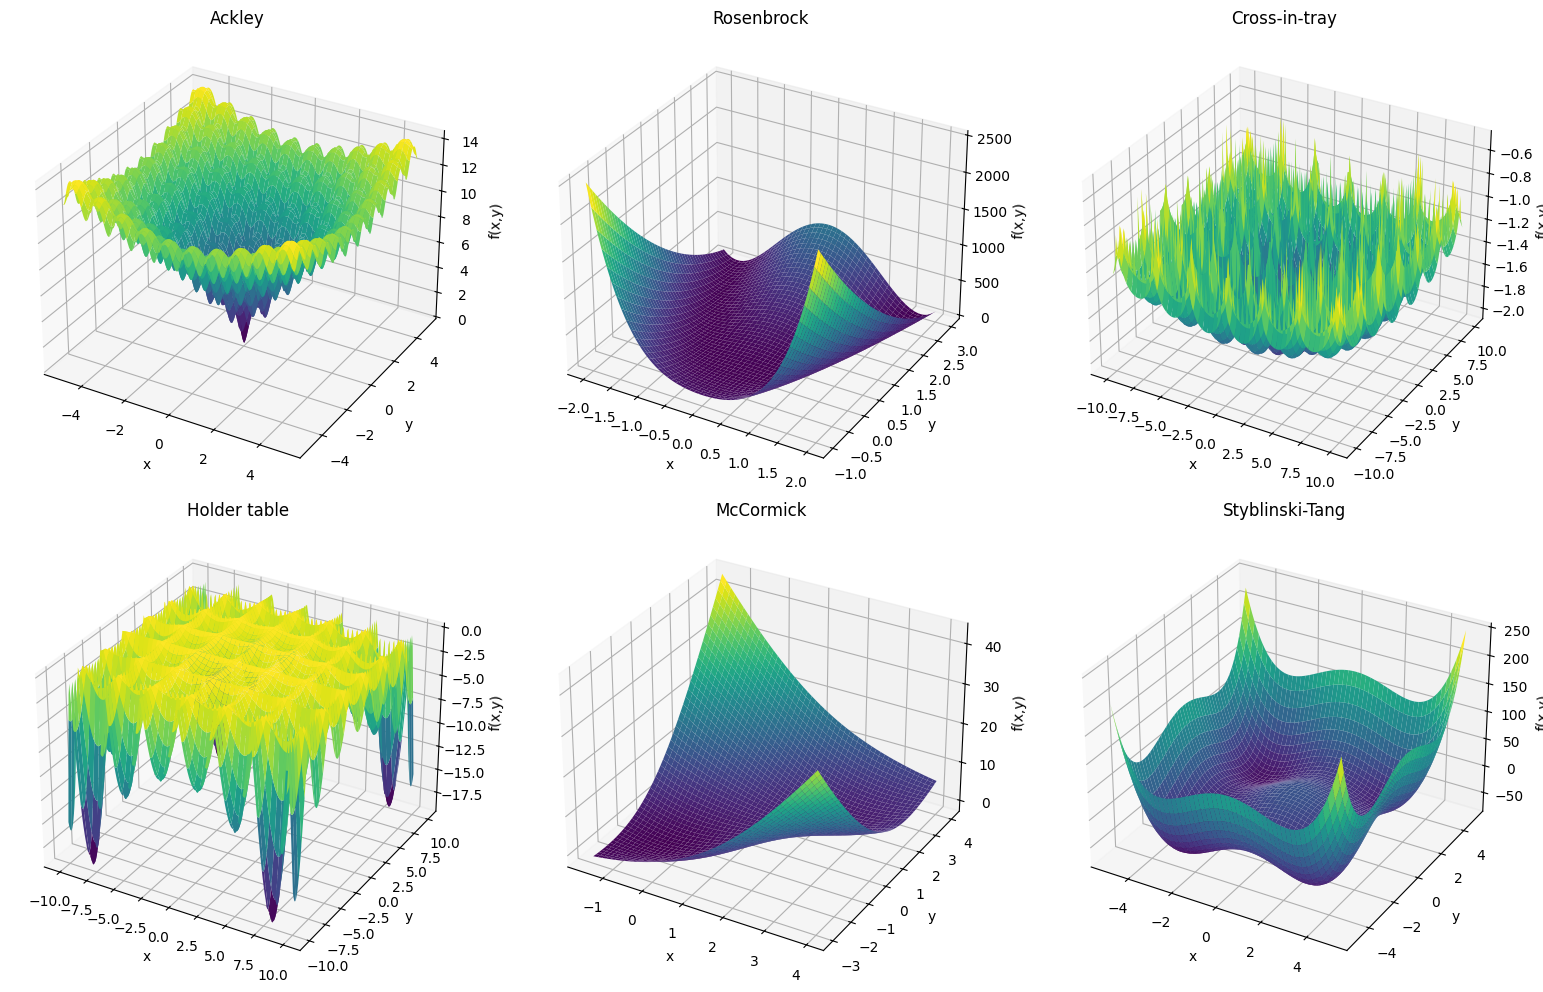

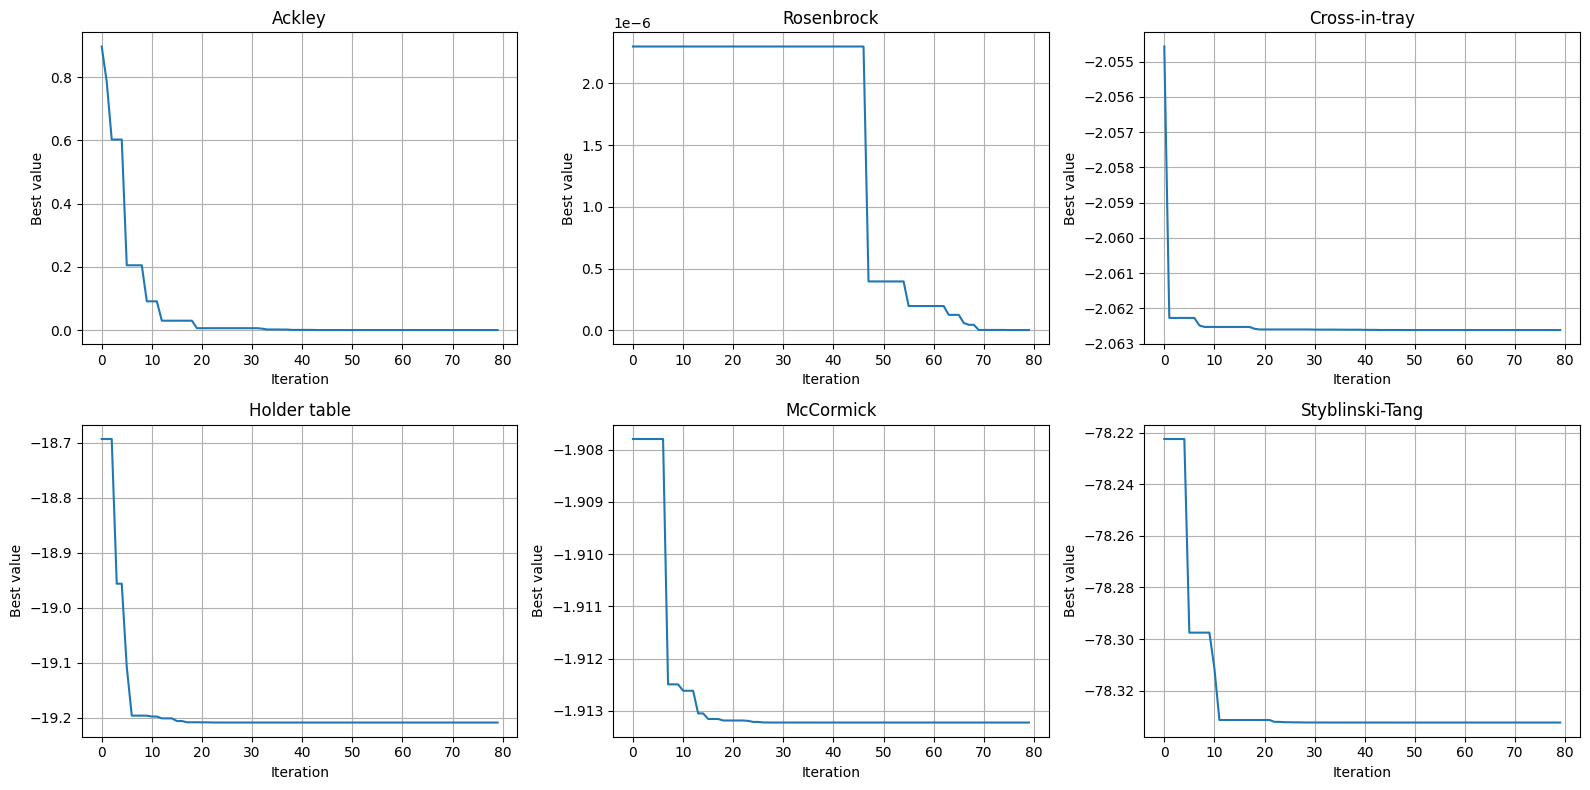

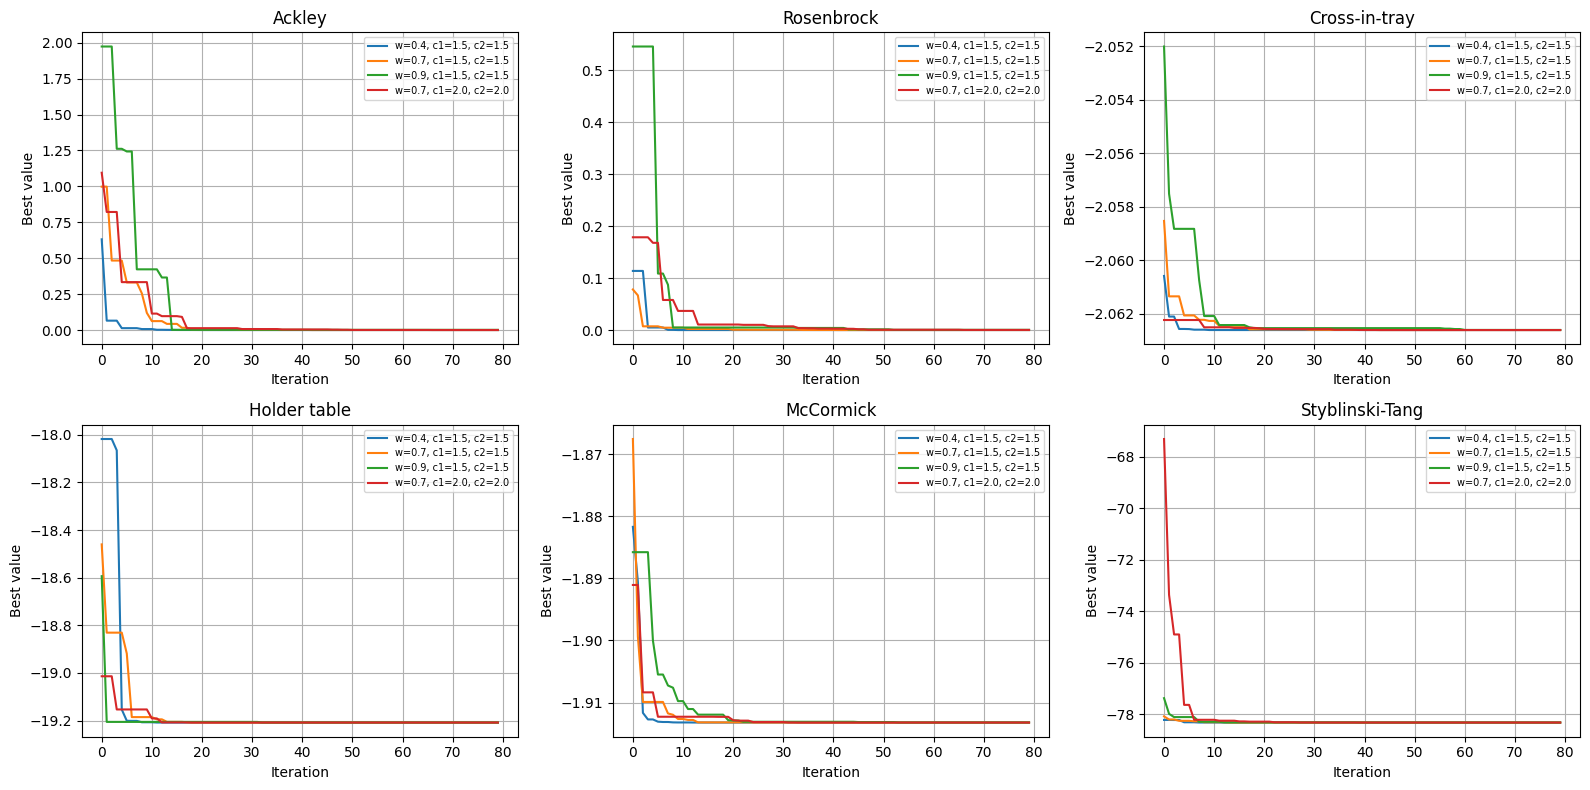

In [23]:
functions = [
    ("Ackley", ackley, ((-5,5),(-5,5)), "ackley.gif"),
    ("Rosenbrock", rosenbrock, ((-2,2),(-1,3)), "rosenbrock.gif"),
    ("Cross-in-tray", cross_in_tray, ((-10,10),(-10,10)), "cross.gif"),
    ("Holder table", holder_table, ((-10,10),(-10,10)), "holder.gif"),
    ("McCormick", mccormick, ((-1.5,4),(-3,4)), "mccormick.gif"),
    ("Styblinski-Tang", styblinski_tang, ((-5,5),(-5,5)), "styblinski.gif")
]



# 3D графіки функцій 
def plot_all_functions_3d(functions):

    fig = plt.figure(figsize=(16,10))

    for i, (name, func, bounds, _) in enumerate(functions):

        (xmin, xmax), (ymin, ymax) = bounds

        x = np.linspace(xmin, xmax, 200)
        y = np.linspace(ymin, ymax, 200)

        X, Y = np.meshgrid(x, y)
        Z = func(X, Y)

        ax = fig.add_subplot(2, 3, i+1, projection="3d")

        ax.plot_surface(X, Y, Z, cmap="viridis")

        ax.set_title(name)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("f(x,y)")

    plt.tight_layout()
    plt.show()


plot_all_functions_3d(functions)



results = []

for name, func, bounds, gif_name in functions:

    best, val, history, pops = pso_2d(
        func,
        bounds=bounds,
        swarm_size=80,
        iterations=80
    )

    save_gif_3d(func, bounds, pops, history, gif_name)

    results.append((name, history))


# Графіки збіжності
fig, axes = plt.subplots(2, 3, figsize=(16,8))

for i, (name, history) in enumerate(results):

    row = i // 3
    col = i % 3

    axes[row, col].plot(history)

    axes[row, col].set_title(name)
    axes[row, col].set_xlabel("Iteration")
    axes[row, col].set_ylabel("Best value")

    axes[row, col].grid(True)

plt.tight_layout()
plt.show()


# Графіки з параметрами
def compare_parameters_all(functions):

    params = [
        (0.4,1.5,1.5),
        (0.7,1.5,1.5),
        (0.9,1.5,1.5),
        (0.7,2.0,2.0)
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16,8))

    for i, (name, func, bounds, _) in enumerate(functions):

        row = i // 3
        col = i % 3

        for w, c1, c2 in params:

            _, _, history, _ = pso_2d(
                func,
                bounds=bounds,
                swarm_size=80,
                iterations=80,
                w=w,
                c1=c1,
                c2=c2
            )

            axes[row, col].plot(history, label=f"w={w}, c1={c1}, c2={c2}")

        axes[row, col].set_title(name)
        axes[row, col].set_xlabel("Iteration")
        axes[row, col].set_ylabel("Best value")
        axes[row, col].grid(True)
        axes[row, col].legend(fontsize=7)

    plt.tight_layout()
    plt.show()


compare_parameters_all(functions)